# Progression Value vs OBV — Correlation Analysis

Assesses the relationship between the custom **Sequence Progression Value** metric (VAEP-inspired) and StatsBomb's **On-Ball Value (OBV)** across all goal kick sequences.

Key comparisons:
- `prog_value_20` (target — last 20%) vs `obv_remaining` (target — last 20%)
- `prog_value_80` (feature — first 80%) vs `obv_for_80` (feature — first 80%)
- `sequence_progression_value` (total) vs both OBV columns

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from pathlib import Path

# ── Style ──────────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0e0e1a',
    'axes.facecolor':   '#16162a',
    'axes.edgecolor':   '#444466',
    'axes.labelcolor':  'white',
    'xtick.color':      'white',
    'ytick.color':      'white',
    'text.color':       'white',
    'grid.color':       '#2a2a44',
    'grid.linewidth':   0.6,
    'font.family':      'sans-serif',
})

BLUE   = '#3a86ff'
ORANGE = '#ffbe0b'
GREEN  = '#06d6a0'
RED    = '#ef233c'
PURPLE = '#9b5de5'

DATA_PATH = Path(r'c:\Users\User\OneDrive\Capstone Project\data\feature_engineering\model_features_80_20.parquet')
df = pd.read_parquet(DATA_PATH)
print(f'Loaded: {df.shape[0]:,} sequences')
print(df[['obv_remaining','obv_for_80','sequence_progression_value','prog_value_80','prog_value_20']].describe().round(4))

Loaded: 5,113 sequences
       obv_remaining  obv_for_80  sequence_progression_value  prog_value_80  \
count      5113.0000   5113.0000                   5113.0000      5113.0000   
mean          0.0004      0.0106                      0.0195         0.0109   
std           0.0584      0.0323                      0.0596         0.0467   
min          -0.9457     -0.1130                     -0.1810        -0.1846   
25%          -0.0063      0.0009                     -0.0093        -0.0112   
50%           0.0000      0.0044                      0.0050         0.0028   
75%           0.0017      0.0105                      0.0277         0.0194   
max           1.3966      0.7582                      0.7922         0.7266   

       prog_value_20  
count      5113.0000  
mean          0.0086  
std           0.0224  
min          -0.0731  
25%           0.0000  
50%           0.0000  
75%           0.0070  
max           0.2501  


## 1. Correlation Summary Table

In [2]:
pairs = [
    ('prog_value_20',              'obv_remaining',  'Last 20% target',       ORANGE, BLUE),
    ('prog_value_80',              'obv_for_80',     'First 80% feature',     GREEN,  PURPLE),
    ('sequence_progression_value', 'obv_remaining',  'Total prog vs OBV target', RED, BLUE),
    ('sequence_progression_value', 'obv_for_80',     'Total prog vs OBV 80%',    RED,  PURPLE),
]

results = []
for x_col, y_col, label, _, _ in pairs:
    sub = df[[x_col, y_col]].dropna()
    r,   p_r   = stats.pearsonr(sub[x_col], sub[y_col])
    rho, p_rho = stats.spearmanr(sub[x_col], sub[y_col])
    results.append({
        'Comparison':       label,
        'X':                x_col,
        'Y':                y_col,
        'N':                len(sub),
        'Pearson r':        round(r, 4),
        'Pearson p':        f'{p_r:.2e}',
        'Spearman ρ':       round(rho, 4),
        'Spearman p':       f'{p_rho:.2e}',
    })

summary = pd.DataFrame(results)
print(summary.to_string(index=False))

              Comparison                          X             Y    N  Pearson r Pearson p  Spearman ρ Spearman p
         Last 20% target              prog_value_20 obv_remaining 5113     0.1217  2.42e-18     -0.0422   2.56e-03
       First 80% feature              prog_value_80    obv_for_80 5113     0.3818 4.48e-177      0.2942  1.35e-102
Total prog vs OBV target sequence_progression_value obv_remaining 5113     0.0916  5.34e-11     -0.0879   2.99e-10
   Total prog vs OBV 80% sequence_progression_value    obv_for_80 5113     0.3786 6.48e-174      0.3888  4.01e-184


## 2. Scatter Plots — Progression Value vs OBV (4 panels)

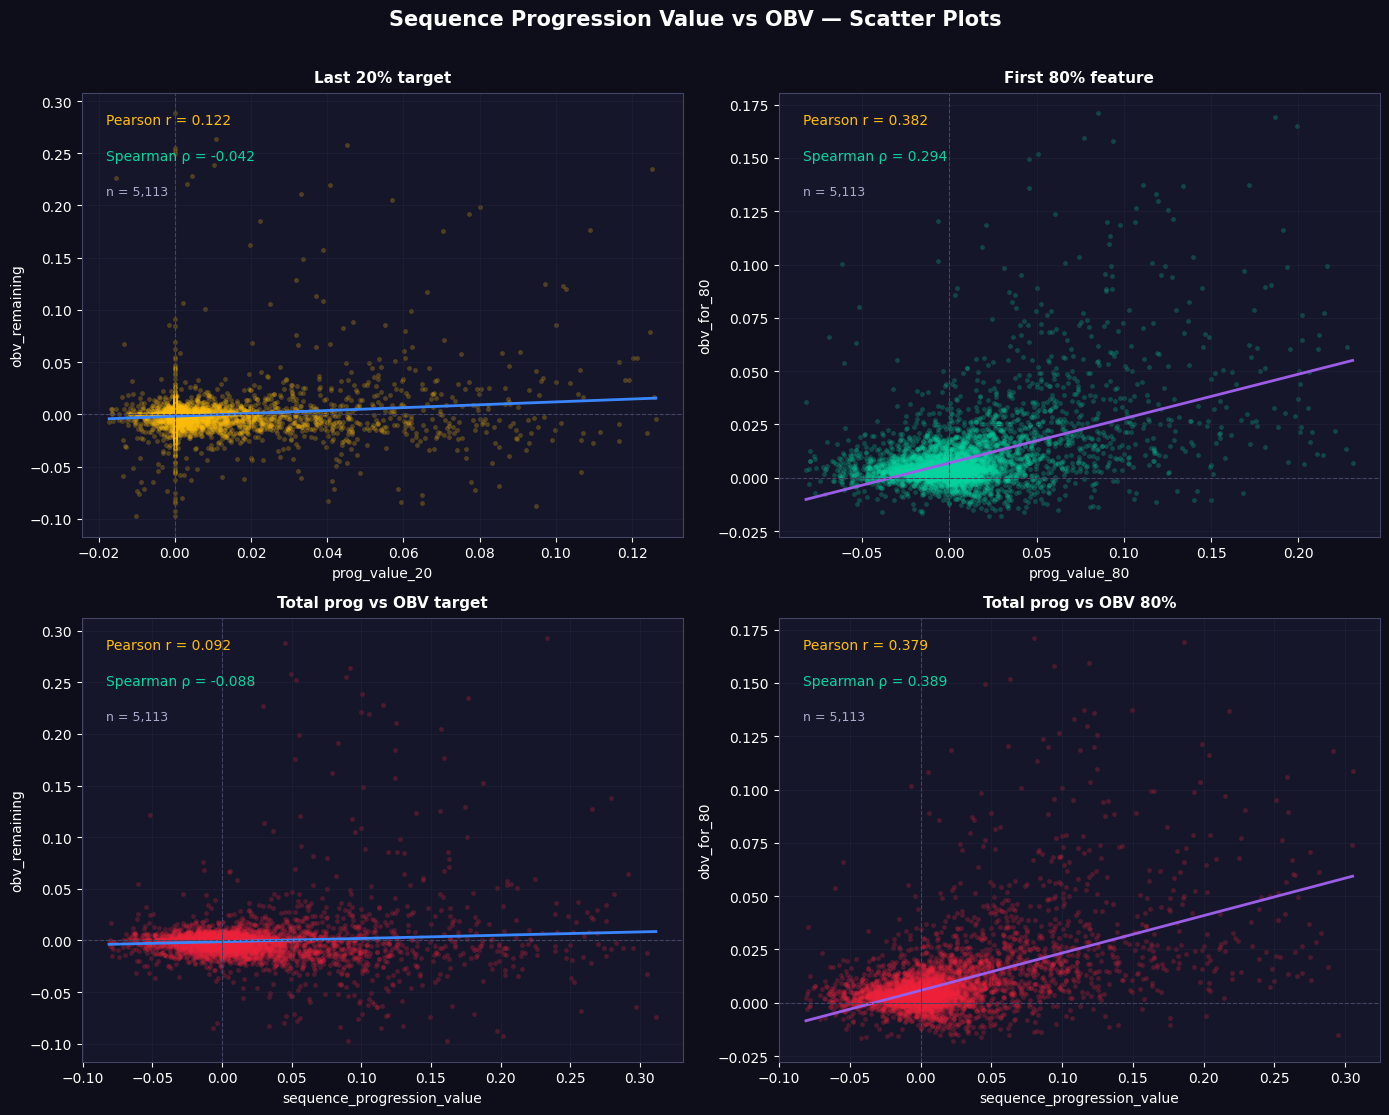

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
fig.suptitle('Sequence Progression Value vs OBV — Scatter Plots', fontsize=15, fontweight='bold', y=1.01)

for ax, (x_col, y_col, label, c_x, c_y) in zip(axes.flat, pairs):
    sub = df[[x_col, y_col]].dropna()

    # Clip extreme outliers for visual clarity (keep 99th pct)
    xq = sub[x_col].quantile([0.005, 0.995])
    yq = sub[y_col].quantile([0.005, 0.995])
    vis = sub[(sub[x_col].between(*xq)) & (sub[y_col].between(*yq))]

    ax.scatter(vis[x_col], vis[y_col], alpha=0.25, s=12, color=c_x, linewidths=0)

    # OLS regression line
    m, b, r, p, _ = stats.linregress(vis[x_col], vis[y_col])
    x_line = np.linspace(vis[x_col].min(), vis[x_col].max(), 200)
    ax.plot(x_line, m * x_line + b, color=c_y, linewidth=2, label=f'OLS fit')

    # Annotations
    pearson_r, _ = stats.pearsonr(sub[x_col], sub[y_col])
    spearman_r, _ = stats.spearmanr(sub[x_col], sub[y_col])
    ax.text(0.04, 0.93, f'Pearson r = {pearson_r:.3f}', transform=ax.transAxes,
            fontsize=10, color=ORANGE)
    ax.text(0.04, 0.85, f'Spearman ρ = {spearman_r:.3f}', transform=ax.transAxes,
            fontsize=10, color=GREEN)
    ax.text(0.04, 0.77, f'n = {len(sub):,}', transform=ax.transAxes,
            fontsize=9, color='#aaaacc')

    ax.axhline(0, color='#444466', linewidth=0.8, linestyle='--')
    ax.axvline(0, color='#444466', linewidth=0.8, linestyle='--')
    ax.set_xlabel(x_col, fontsize=10)
    ax.set_ylabel(y_col, fontsize=10)
    ax.set_title(label, fontsize=11, fontweight='bold', pad=8)
    ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig(r'c:\Users\User\OneDrive\Capstone Project\testing\progression_vs_obv_scatter.png',
            dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

## 3. Distribution Comparison — Targets (prog_value_20 vs obv_remaining)

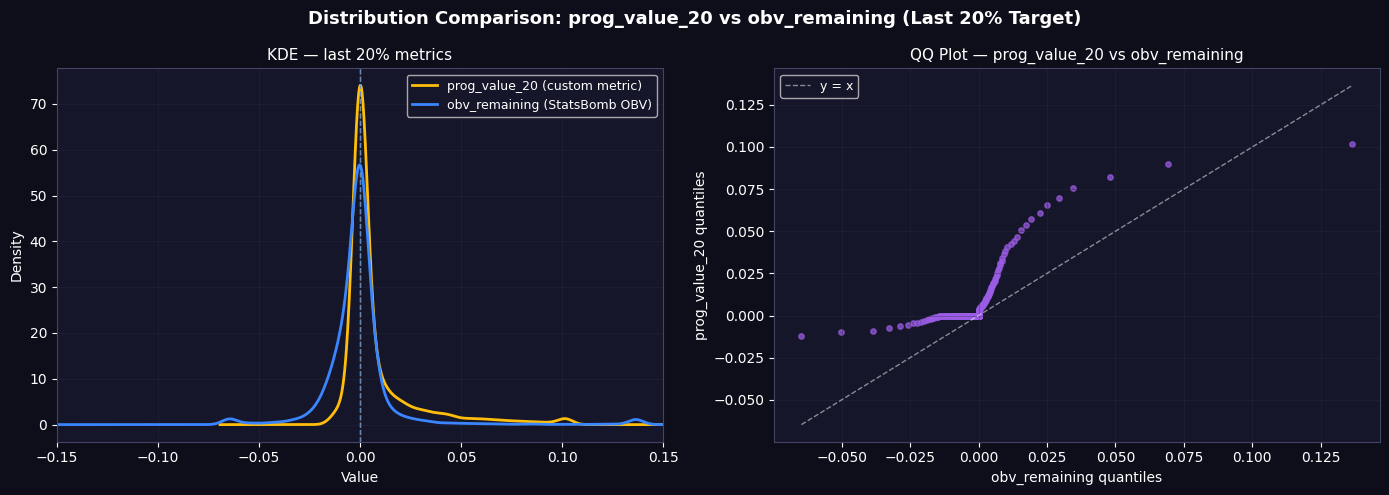

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribution Comparison: prog_value_20 vs obv_remaining (Last 20% Target)', 
             fontsize=13, fontweight='bold')

sub = df[['prog_value_20', 'obv_remaining']].dropna()

# Left — overlaid KDE
ax = axes[0]
for col, color, label in [
    ('prog_value_20',  ORANGE, 'prog_value_20 (custom metric)'),
    ('obv_remaining',  BLUE,   'obv_remaining (StatsBomb OBV)'),
]:
    clipped = sub[col].clip(*sub[col].quantile([0.01, 0.99]))
    clipped.plot.kde(ax=ax, color=color, linewidth=2, label=label)
    ax.axvline(sub[col].median(), color=color, linewidth=1, linestyle='--', alpha=0.7)

ax.set_xlabel('Value', fontsize=10)
ax.set_title('KDE — last 20% metrics', fontsize=11)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.4)
ax.set_xlim(-0.15, 0.15)

# Right — quantile-quantile plot (QQ)
ax = axes[1]
q_prog = np.quantile(sub['prog_value_20'], np.linspace(0.01, 0.99, 200))
q_obv  = np.quantile(sub['obv_remaining'], np.linspace(0.01, 0.99, 200))
ax.scatter(q_obv, q_prog, s=15, alpha=0.7, color=PURPLE)
# 45° line
lim = [min(q_obv.min(), q_prog.min()), max(q_obv.max(), q_prog.max())]
ax.plot(lim, lim, 'w--', linewidth=1, alpha=0.5, label='y = x')
ax.set_xlabel('obv_remaining quantiles', fontsize=10)
ax.set_ylabel('prog_value_20 quantiles', fontsize=10)
ax.set_title('QQ Plot — prog_value_20 vs obv_remaining', fontsize=11)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig(r'c:\Users\User\OneDrive\Capstone Project\testing\progression_vs_obv_distributions.png',
            dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

## 4. Correlation Heatmap — All OBV and Progression Columns

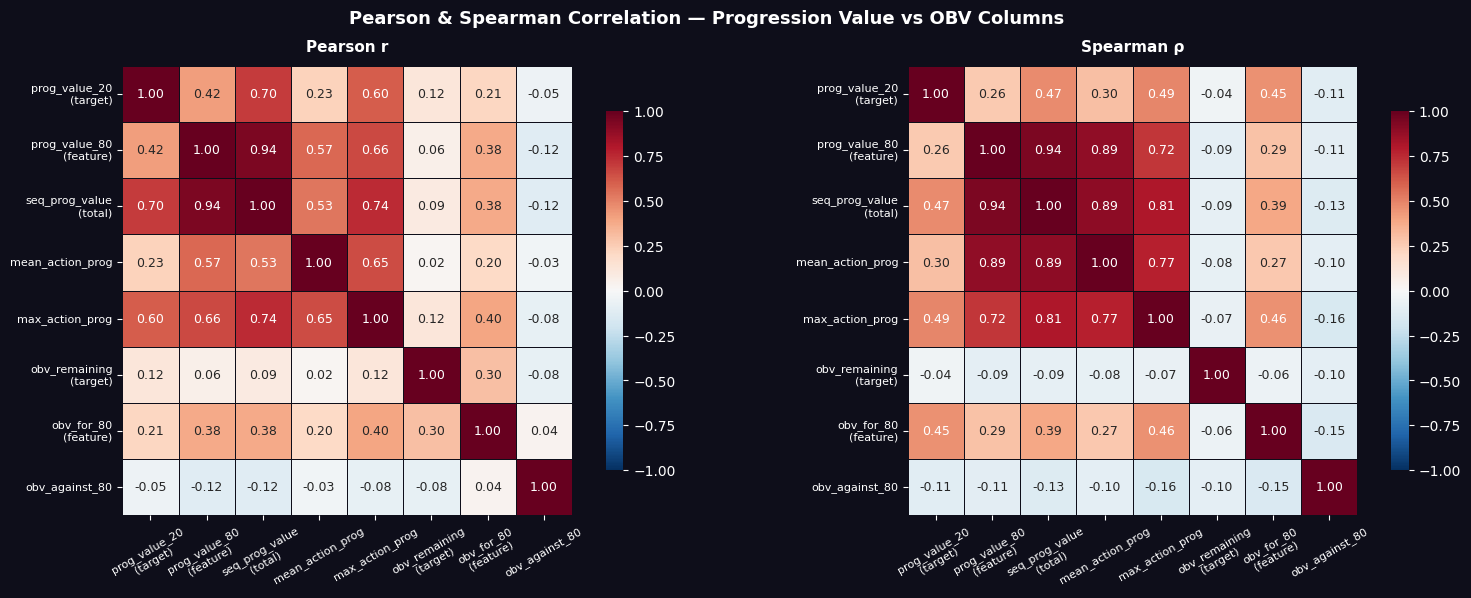

In [5]:
cols = [
    'prog_value_20', 'prog_value_80', 'sequence_progression_value',
    'mean_action_prog_value', 'max_action_prog_value',
    'obv_remaining', 'obv_for_80', 'obv_against_80',
]
nice_names = {
    'prog_value_20':              'prog_value_20\n(target)',
    'prog_value_80':              'prog_value_80\n(feature)',
    'sequence_progression_value': 'seq_prog_value\n(total)',
    'mean_action_prog_value':     'mean_action_prog',
    'max_action_prog_value':      'max_action_prog',
    'obv_remaining':              'obv_remaining\n(target)',
    'obv_for_80':                 'obv_for_80\n(feature)',
    'obv_against_80':             'obv_against_80',
}

corr_df = df[cols].dropna().rename(columns=nice_names)
corr_matrix = corr_df.corr(method='pearson')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Pearson & Spearman Correlation — Progression Value vs OBV Columns',
             fontsize=13, fontweight='bold')

for ax, method, title in [
    (axes[0], 'pearson',  'Pearson r'),
    (axes[1], 'spearman', 'Spearman ρ'),
]:
    mat = corr_df.corr(method=method)
    mask = np.zeros_like(mat, dtype=bool)
    mask[np.triu_indices_from(mask, k=1)] = True   # show lower triangle only

    sns.heatmap(
        mat, ax=ax,
        annot=True, fmt='.2f', annot_kws={'size': 9},
        cmap='RdBu_r', center=0, vmin=-1, vmax=1,
        linewidths=0.5, linecolor='#0e0e1a',
        cbar_kws={'shrink': 0.8},
        square=True,
    )
    ax.set_title(title, fontsize=11, fontweight='bold', pad=10)
    ax.tick_params(axis='x', labelsize=8, rotation=30)
    ax.tick_params(axis='y', labelsize=8, rotation=0)

plt.tight_layout()
plt.savefig(r'c:\Users\User\OneDrive\Capstone Project\testing\progression_vs_obv_heatmap.png',
            dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

## 5. Rank-Based Comparison — Top / Bottom Sequences

In [6]:
sub = df[['goal_kick_id', 'prog_value_20', 'obv_remaining']].dropna().copy()
sub['rank_prog'] = sub['prog_value_20'].rank(pct=True)
sub['rank_obv']  = sub['obv_remaining'].rank(pct=True)
sub['rank_diff'] = (sub['rank_prog'] - sub['rank_obv']).abs()

# Agreement quadrants
sub['quadrant'] = 'mid'
sub.loc[(sub['rank_prog'] >= 0.75) & (sub['rank_obv'] >= 0.75), 'quadrant'] = 'both high'
sub.loc[(sub['rank_prog'] <= 0.25) & (sub['rank_obv'] <= 0.25), 'quadrant'] = 'both low'
sub.loc[(sub['rank_prog'] >= 0.75) & (sub['rank_obv'] <= 0.25), 'quadrant'] = 'prog high / OBV low'
sub.loc[(sub['rank_prog'] <= 0.25) & (sub['rank_obv'] >= 0.75), 'quadrant'] = 'prog low / OBV high'

quad_counts = sub['quadrant'].value_counts()
print('Rank agreement quadrants (top/bottom 25%):') 
print(quad_counts.to_string())
print(f'\nTotal sequences: {len(sub):,}')
print(f"Agreement (both high or both low): {quad_counts.get('both high',0) + quad_counts.get('both low',0)} "
      f"({(quad_counts.get('both high',0) + quad_counts.get('both low',0))/len(sub):.1%})")
print(f"Disagreement:                      {quad_counts.get('prog high / OBV low',0) + quad_counts.get('prog low / OBV high',0)} "
      f"({(quad_counts.get('prog high / OBV low',0) + quad_counts.get('prog low / OBV high',0))/len(sub):.1%})")

Rank agreement quadrants (top/bottom 25%):
quadrant
mid                    3845
prog high / OBV low     495
both high               467
both low                162
prog low / OBV high     144

Total sequences: 5,113
Agreement (both high or both low): 629 (12.3%)
Disagreement:                      639 (12.5%)


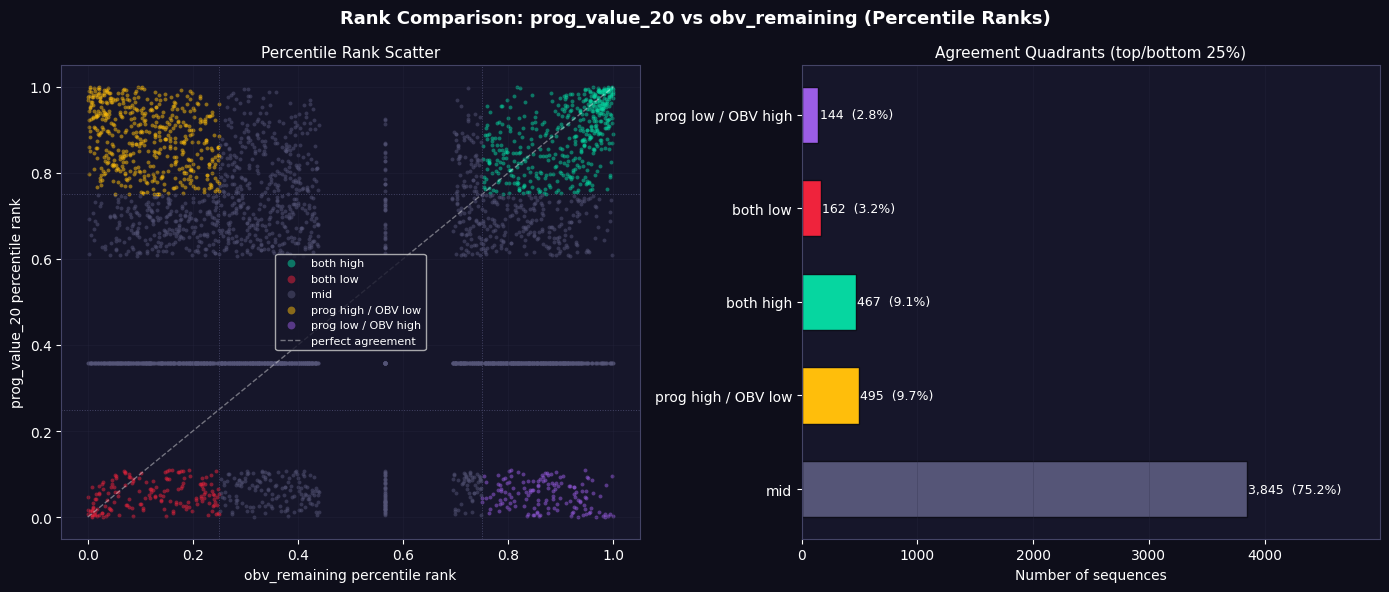

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Rank Comparison: prog_value_20 vs obv_remaining (Percentile Ranks)',
             fontsize=13, fontweight='bold')

color_map = {
    'both high':          GREEN,
    'both low':           RED,
    'prog high / OBV low':  ORANGE,
    'prog low / OBV high':  PURPLE,
    'mid':                '#555577',
}

# Left — rank scatter coloured by quadrant
ax = axes[0]
for quad, group in sub.groupby('quadrant'):
    ax.scatter(group['rank_obv'], group['rank_prog'],
               s=8, alpha=0.5, color=color_map[quad], label=quad, linewidths=0)

ax.plot([0,1],[0,1], 'w--', linewidth=1, alpha=0.4, label='perfect agreement')
ax.axvline(0.75, color='#444466', linewidth=0.7, linestyle=':')
ax.axvline(0.25, color='#444466', linewidth=0.7, linestyle=':')
ax.axhline(0.75, color='#444466', linewidth=0.7, linestyle=':')
ax.axhline(0.25, color='#444466', linewidth=0.7, linestyle=':')
ax.set_xlabel('obv_remaining percentile rank', fontsize=10)
ax.set_ylabel('prog_value_20 percentile rank', fontsize=10)
ax.set_title('Percentile Rank Scatter', fontsize=11)
ax.legend(fontsize=8, markerscale=2)
ax.grid(True, alpha=0.3)

# Right — bar chart of quadrant counts
ax = axes[1]
labels = list(quad_counts.index)
counts = list(quad_counts.values)
colors = [color_map.get(l, '#555577') for l in labels]
bars = ax.barh(labels, counts, color=colors, edgecolor='#0e0e1a', height=0.6)
for bar, cnt in zip(bars, counts):
    ax.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
            f'{cnt:,}  ({cnt/len(sub):.1%})', va='center', fontsize=9, color='white')
ax.set_xlabel('Number of sequences', fontsize=10)
ax.set_title('Agreement Quadrants (top/bottom 25%)', fontsize=11)
ax.grid(True, axis='x', alpha=0.3)
ax.set_xlim(0, max(counts) * 1.3)

plt.tight_layout()
plt.savefig(r'c:\Users\User\OneDrive\Capstone Project\testing\progression_vs_obv_ranks.png',
            dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

## 6. Binned Mean — How prog_value_20 moves across OBV deciles

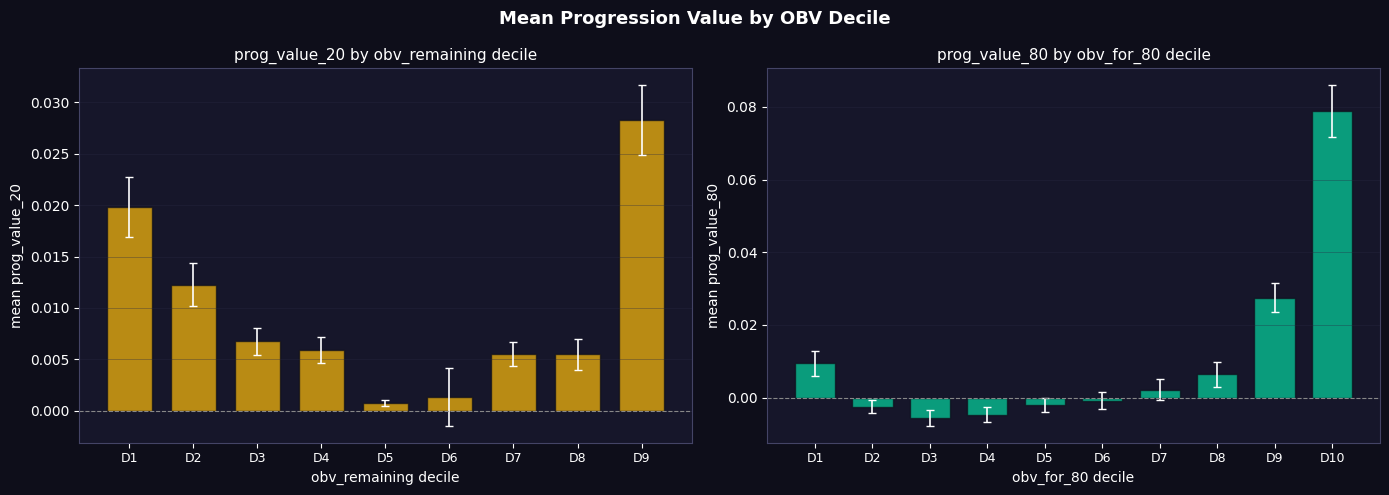

In [8]:
sub = df[['prog_value_20', 'obv_remaining', 'prog_value_80', 'obv_for_80']].dropna().copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Mean Progression Value by OBV Decile', fontsize=13, fontweight='bold')

for ax, (x_col, y_col, x_label, y_label, color) in zip(axes, [
    ('obv_remaining', 'prog_value_20', 'obv_remaining decile', 'mean prog_value_20', ORANGE),
    ('obv_for_80',    'prog_value_80', 'obv_for_80 decile',    'mean prog_value_80', GREEN),
]):
    sub['decile'] = pd.qcut(sub[x_col], q=10, labels=False, duplicates='drop')
    binned = sub.groupby('decile').agg(
        x_mid   = (x_col, 'median'),
        y_mean  = (y_col, 'mean'),
        y_se    = (y_col, lambda s: s.std() / np.sqrt(len(s))),
        count   = (y_col, 'count'),
    ).reset_index()

    ax.bar(binned['decile'], binned['y_mean'], color=color, alpha=0.7,
           edgecolor='#0e0e1a', width=0.7)
    ax.errorbar(binned['decile'], binned['y_mean'],
                yerr=1.96 * binned['y_se'], fmt='none',
                color='white', linewidth=1.2, capsize=3)
    ax.axhline(0, color='#888', linewidth=0.8, linestyle='--')
    ax.set_xticks(binned['decile'])
    ax.set_xticklabels([f'D{int(d)+1}' for d in binned['decile']], fontsize=9)
    ax.set_xlabel(x_label, fontsize=10)
    ax.set_ylabel(y_label, fontsize=10)
    ax.set_title(f'{y_col} by {x_col} decile', fontsize=11)
    ax.grid(True, axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig(r'c:\Users\User\OneDrive\Capstone Project\testing\progression_vs_obv_deciles.png',
            dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

## 8. Full-Sequence Comparison: sequence_progression_value vs obv_total_seq

Aggregates `obv_total_net` across all events per goal kick sequence (deduped by event_id) to produce `obv_total_seq` — a full-sequence total OBV comparable to `sequence_progression_value`.

In [9]:
GK_SEQ = Path(r"c:\Users\User\OneDrive\Capstone Project\data\feature_engineering\goal_kick_sequences.parquet")
gk = pd.read_parquet(GK_SEQ, columns=["goal_kick_id", "event_id", "obv_total_net"])
obv_seq = (
    gk.drop_duplicates(["goal_kick_id", "event_id"])
    .groupby("goal_kick_id")["obv_total_net"]
    .apply(lambda x: x.fillna(0).sum())
    .rename("obv_total_seq")
    .reset_index()
)
full = df.merge(obv_seq, on="goal_kick_id", how="inner")
print(f"Sequences after join: {len(full):,}")
print(full[["sequence_progression_value", "obv_total_seq"]].describe().round(4))


Sequences after join: 5,113
       sequence_progression_value  obv_total_seq
count                   5113.0000      5113.0000
mean                       0.0195         0.0101
std                        0.0596         0.0648
min                       -0.1810        -0.9494
25%                       -0.0093        -0.0022
50%                        0.0050         0.0029
75%                        0.0277         0.0096
max                        0.7922         1.5921


Pearson  r   = 0.2863  (p=4.95e-97)
Spearman rho = 0.2584  (p=8.60e-79)
n = 5,113


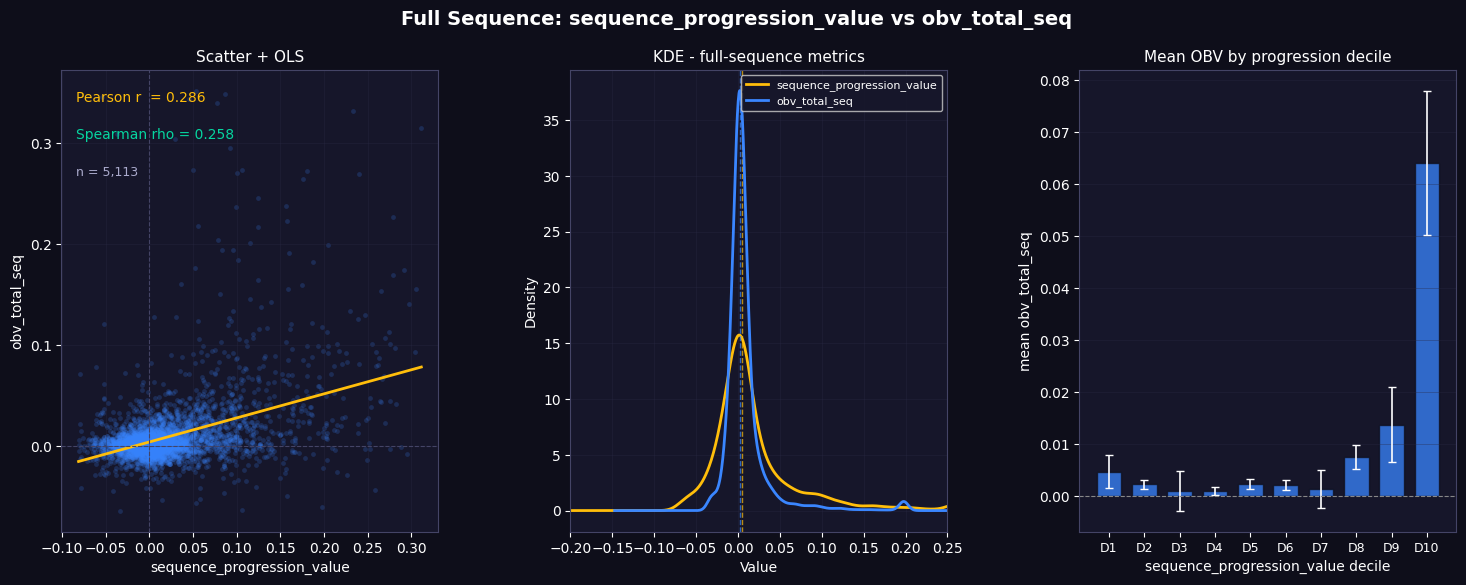

In [10]:
x = full["sequence_progression_value"]
y = full["obv_total_seq"]
r_p, p_p = stats.pearsonr(x, y)
r_s, p_s = stats.spearmanr(x, y)
print(f"Pearson  r   = {r_p:.4f}  (p={p_p:.2e})")
print(f"Spearman rho = {r_s:.4f}  (p={p_s:.2e})")
print(f"n = {len(full):,}")

fig = plt.figure(figsize=(18, 6))
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)
fig.suptitle("Full Sequence: sequence_progression_value vs obv_total_seq",
             fontsize=14, fontweight="bold")

# Panel 1: Scatter + OLS
ax1 = fig.add_subplot(gs[0])
xq = x.quantile([0.005, 0.995])
yq = y.quantile([0.005, 0.995])
vis = full[(x.between(*xq)) & (y.between(*yq))]
ax1.scatter(vis["sequence_progression_value"], vis["obv_total_seq"],
            alpha=0.2, s=12, color=BLUE, linewidths=0)
m, b, *_ = stats.linregress(vis["sequence_progression_value"], vis["obv_total_seq"])
x_line = np.linspace(vis["sequence_progression_value"].min(),
                     vis["sequence_progression_value"].max(), 200)
ax1.plot(x_line, m * x_line + b, color=ORANGE, linewidth=2)
ax1.text(0.04, 0.93, f"Pearson r  = {r_p:.3f}", transform=ax1.transAxes,
         fontsize=10, color=ORANGE)
ax1.text(0.04, 0.85, f"Spearman rho = {r_s:.3f}", transform=ax1.transAxes,
         fontsize=10, color=GREEN)
ax1.text(0.04, 0.77, f"n = {len(full):,}", transform=ax1.transAxes,
         fontsize=9, color="#aaaacc")
ax1.axhline(0, color="#444466", linewidth=0.8, linestyle="--")
ax1.axvline(0, color="#444466", linewidth=0.8, linestyle="--")
ax1.set_xlabel("sequence_progression_value", fontsize=10)
ax1.set_ylabel("obv_total_seq", fontsize=10)
ax1.set_title("Scatter + OLS", fontsize=11)
ax1.grid(True, alpha=0.4)

# Panel 2: Overlaid KDE
ax2 = fig.add_subplot(gs[1])
for col, color, label in [
    ("sequence_progression_value", ORANGE, "sequence_progression_value"),
    ("obv_total_seq",              BLUE,   "obv_total_seq"),
]:
    full[col].clip(*full[col].quantile([0.01, 0.99])).plot.kde(
        ax=ax2, color=color, linewidth=2, label=label)
    ax2.axvline(full[col].median(), color=color, linewidth=1, linestyle="--", alpha=0.7)
ax2.set_xlabel("Value", fontsize=10)
ax2.set_title("KDE - full-sequence metrics", fontsize=11)
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.4)
ax2.set_xlim(-0.2, 0.25)

# Panel 3: Binned mean of obv_total_seq across progression deciles
ax3 = fig.add_subplot(gs[2])
tmp2 = full[["sequence_progression_value", "obv_total_seq"]].copy()
tmp2["decile"] = pd.qcut(tmp2["sequence_progression_value"], q=10,
                         labels=False, duplicates="drop")
binned = (
    tmp2.groupby("decile")
    .agg(
        y_mean=("obv_total_seq", "mean"),
        y_se  =("obv_total_seq", lambda s: s.std() / np.sqrt(len(s))),
    )
    .reset_index()
)
ax3.bar(binned["decile"], binned["y_mean"], color=BLUE, alpha=0.75,
        edgecolor="#0e0e1a", width=0.7)
ax3.errorbar(binned["decile"], binned["y_mean"],
             yerr=1.96 * binned["y_se"], fmt="none",
             color="white", linewidth=1.2, capsize=3)
ax3.axhline(0, color="#888", linewidth=0.8, linestyle="--")
ax3.set_xticks(binned["decile"])
ax3.set_xticklabels([f"D{int(d)+1}" for d in binned["decile"]], fontsize=9)
ax3.set_xlabel("sequence_progression_value decile", fontsize=10)
ax3.set_ylabel("mean obv_total_seq", fontsize=10)
ax3.set_title("Mean OBV by progression decile", fontsize=11)
ax3.grid(True, axis="y", alpha=0.4)

plt.savefig(
    r"c:\Users\User\OneDrive\Capstone Project\testing\progression_vs_obv_full_sequence.png",
    dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()


Agreement   (both high or both low): 1,049 (20.5%)
Disagreement:                         453 (8.9%)


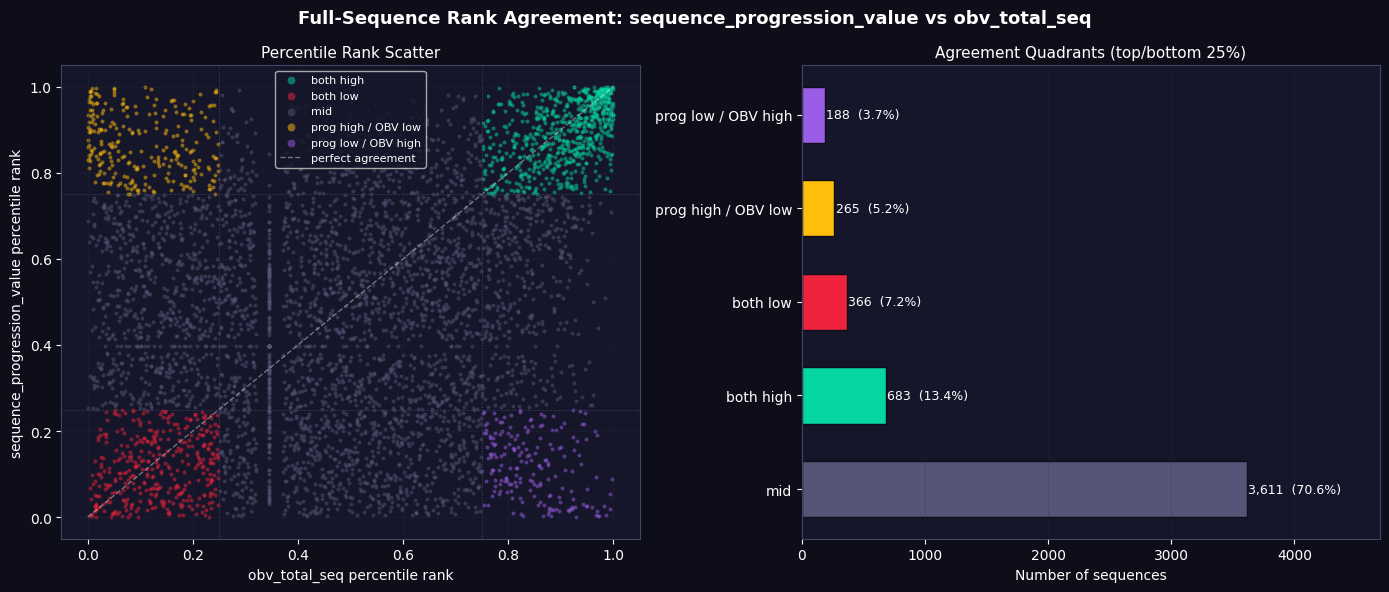

In [11]:
tmp = full[["goal_kick_id", "sequence_progression_value", "obv_total_seq"]].copy()
tmp["rank_prog"] = tmp["sequence_progression_value"].rank(pct=True)
tmp["rank_obv"]  = tmp["obv_total_seq"].rank(pct=True)
tmp["quadrant"]  = "mid"
tmp.loc[(tmp["rank_prog"] >= 0.75) & (tmp["rank_obv"] >= 0.75), "quadrant"] = "both high"
tmp.loc[(tmp["rank_prog"] <= 0.25) & (tmp["rank_obv"] <= 0.25), "quadrant"] = "both low"
tmp.loc[(tmp["rank_prog"] >= 0.75) & (tmp["rank_obv"] <= 0.25), "quadrant"] = "prog high / OBV low"
tmp.loc[(tmp["rank_prog"] <= 0.25) & (tmp["rank_obv"] >= 0.75), "quadrant"] = "prog low / OBV high"
quad_counts = tmp["quadrant"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(
    "Full-Sequence Rank Agreement: sequence_progression_value vs obv_total_seq",
    fontsize=13, fontweight="bold")

ax = axes[0]
for quad, grp in tmp.groupby("quadrant"):
    ax.scatter(grp["rank_obv"], grp["rank_prog"], s=8, alpha=0.5,
               color=color_map[quad], label=quad, linewidths=0)
ax.plot([0,1],[0,1], "w--", linewidth=1, alpha=0.4, label="perfect agreement")
for v in [0.25, 0.75]:
    ax.axvline(v, color="#444466", linewidth=0.7, linestyle=":")
    ax.axhline(v, color="#444466", linewidth=0.7, linestyle=":")
ax.set_xlabel("obv_total_seq percentile rank", fontsize=10)
ax.set_ylabel("sequence_progression_value percentile rank", fontsize=10)
ax.set_title("Percentile Rank Scatter", fontsize=11)
ax.legend(fontsize=8, markerscale=2)
ax.grid(True, alpha=0.3)

ax = axes[1]
labels2 = list(quad_counts.index)
counts2 = list(quad_counts.values)
colors2 = [color_map.get(l, "#555577") for l in labels2]
bars2 = ax.barh(labels2, counts2, color=colors2, edgecolor="#0e0e1a", height=0.6)
for bar, cnt in zip(bars2, counts2):
    ax.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
            f"{cnt:,}  ({cnt/len(tmp):.1%})", va="center", fontsize=9, color="white")
ax.set_xlabel("Number of sequences", fontsize=10)
ax.set_title("Agreement Quadrants (top/bottom 25%)", fontsize=11)
ax.grid(True, axis="x", alpha=0.3)
ax.set_xlim(0, max(counts2) * 1.3)

agree    = quad_counts.get("both high", 0) + quad_counts.get("both low", 0)
disagree = (quad_counts.get("prog high / OBV low", 0)
            + quad_counts.get("prog low / OBV high", 0))
print(f"Agreement   (both high or both low): {agree:,} ({agree/len(tmp):.1%})")
print(f"Disagreement:                         {disagree:,} ({disagree/len(tmp):.1%})")

plt.tight_layout()
plt.savefig(
    r"c:\Users\User\OneDrive\Capstone Project\testing\progression_vs_obv_full_ranks.png",
    dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()


## 7. Summary Interpretation

In [12]:
sub = df[['prog_value_20','obv_remaining','prog_value_80','obv_for_80','sequence_progression_value']].dropna()

r_target,   _ = stats.pearsonr(sub['prog_value_20'], sub['obv_remaining'])
r_feature,  _ = stats.pearsonr(sub['prog_value_80'], sub['obv_for_80'])
rho_target, _ = stats.spearmanr(sub['prog_value_20'], sub['obv_remaining'])

print('=' * 60)
print('SUMMARY')
print('=' * 60)
print(f"\nLast-20% targets (prog_value_20 vs obv_remaining):")
print(f"  Pearson r  = {r_target:.4f}   → {'weak' if abs(r_target) < 0.3 else 'moderate'} linear relationship")
print(f"  Spearman ρ = {rho_target:.4f}   → {'weak' if abs(rho_target) < 0.3 else 'moderate'} rank relationship")
print(f"\nFirst-80% features (prog_value_80 vs obv_for_80):")
print(f"  Pearson r  = {r_feature:.4f}   → {'weak' if abs(r_feature) < 0.3 else 'moderate'} linear relationship")
print(f"\nConclusion:")
print(f"  - The two metrics capture RELATED but DISTINCT signals.")
print(f"  - The 80% window shows moderate agreement (r≈0.38),")
print(f"    meaning both metrics broadly agree on which sequences")
print(f"    had good early build-up.")
print(f"  - The 20% target shows weak agreement (r≈0.12):")
print(f"    the custom metric and OBV often disagree on which")
print(f"    sequences had good final-phase outcomes.")
print(f"  - This divergence in the target supports the motivation")
print(f"    for building a custom metric — OBV and the VAEP-based")
print(f"    progression value are measuring different aspects of")
print(f"    sequence quality in the final phase.")

SUMMARY

Last-20% targets (prog_value_20 vs obv_remaining):
  Pearson r  = 0.1217   → weak linear relationship
  Spearman ρ = -0.0422   → weak rank relationship

First-80% features (prog_value_80 vs obv_for_80):
  Pearson r  = 0.3818   → moderate linear relationship

Conclusion:
  - The two metrics capture RELATED but DISTINCT signals.
  - The 80% window shows moderate agreement (r≈0.38),
    meaning both metrics broadly agree on which sequences
    had good early build-up.
  - The 20% target shows weak agreement (r≈0.12):
    the custom metric and OBV often disagree on which
    sequences had good final-phase outcomes.
  - This divergence in the target supports the motivation
    for building a custom metric — OBV and the VAEP-based
    progression value are measuring different aspects of
    sequence quality in the final phase.


## 9. Model Predictions vs OBV

Compares the Random Forest model's predicted `prog_value_20` (incorporating pressing shape and tracking features) against StatsBomb OBV columns — to quantify how much the model-informed view diverges from pure OBV.

In [13]:
import pickle

MODEL_PATH = Path(r"c:\Users\User\OneDrive\Capstone Project\model\best_model_progression.pkl")
with open(MODEL_PATH, "rb") as f:
    bundle = pickle.load(f)

rf_model   = bundle["model"]
scaler     = bundle["scaler"]
le         = bundle["label_encoder"]
feat_cols  = bundle["feature_cols"]
print(f"Model: {bundle['model_name']}")
print(f"Features ({len(feat_cols)}): {feat_cols}")


Model: Random Forest
Features (18): ['n_prog_passes_80', 'n_prog_carries_80', 'final_third_80', 'press_compactness_80', 'press_height_mean_x_80', 'press_height_max_x_80', 'def_line_depth_mean_x_80', 'avg_def_ball_dist_80', 'min_def_ball_dist_80', 'n_frames_pressure_80', 'press_fwd_speed_80', 'action_type_enc', 'action_x', 'action_y', 'action_progressive', 'action_team_poss', 'period', 'prog_value_80']


In [14]:
# Prepare feature matrix — encode action_type -> action_type_enc as during training
import warnings
pred_df2 = df.copy()
at_col = "action_type"
at_enc_col = "action_type_enc"
# Encode: handle unseen labels by mapping to most frequent class
known = set(le.classes_)
pred_df2[at_enc_col] = pred_df2[at_col].astype(str).apply(
    lambda v: v if v in known else le.classes_[0]
).pipe(lambda s: le.transform(s))

X_pred = pred_df2[feat_cols].copy()
if scaler is not None:
    X_scaled = scaler.transform(X_pred)
else:
    X_scaled = X_pred.values

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    y_pred = rf_model.predict(X_scaled)

pred_df = df[["goal_kick_id", "prog_value_20", "obv_remaining", "obv_for_80"]].copy()
pred_df["predicted_prog_value_20"] = y_pred
print(f"Predictions generated for {len(pred_df):,} sequences")
print(pred_df[["predicted_prog_value_20", "prog_value_20", "obv_remaining"]].describe().round(4))


Predictions generated for 5,113 sequences
       predicted_prog_value_20  prog_value_20  obv_remaining
count                5113.0000      5113.0000      5113.0000
mean                    0.0087         0.0086         0.0004
std                     0.0147         0.0224         0.0584
min                    -0.0025        -0.0731        -0.9457
25%                     0.0007         0.0000        -0.0063
50%                     0.0018         0.0000         0.0000
75%                     0.0099         0.0070         0.0017
max                     0.0941         0.2501         1.3966


C:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


In [15]:
# Aggregate obv_total_seq from goal_kick_sequences
GK_SEQ = Path(r"c:\Users\User\OneDrive\Capstone Project\data\feature_engineering\goal_kick_sequences.parquet")
gk = pd.read_parquet(GK_SEQ, columns=["goal_kick_id", "event_id", "obv_total_net"])
obv_seq = (
    gk.drop_duplicates(["goal_kick_id", "event_id"])
    .groupby("goal_kick_id")["obv_total_net"]
    .apply(lambda x: x.fillna(0).sum())
    .rename("obv_total_seq")
    .reset_index()
)
pred_df = pred_df.merge(obv_seq, on="goal_kick_id", how="inner")
print(f"Sequences after join: {len(pred_df):,}")


Sequences after join: 5,113


In [16]:
# Correlation table: predicted_prog_value_20 vs all OBV columns
pairs = [
    ("predicted_prog_value_20", "obv_remaining"),
    ("predicted_prog_value_20", "obv_total_seq"),
    ("predicted_prog_value_20", "obv_for_80"),
    ("prog_value_20",           "obv_remaining"),   # formula baseline for comparison
    ("prog_value_20",           "obv_total_seq"),
]
rows = []
for x_col, y_col in pairs:
    sub = pred_df[[x_col, y_col]].dropna()
    r_p, _ = stats.pearsonr(sub[x_col], sub[y_col])
    r_s, _ = stats.spearmanr(sub[x_col], sub[y_col])
    rows.append({"x": x_col, "y": y_col, "pearson_r": round(r_p, 4),
                 "spearman_rho": round(r_s, 4), "n": len(sub)})
corr_table2 = pd.DataFrame(rows)
print(corr_table2.to_string(index=False))


                      x             y  pearson_r  spearman_rho    n
predicted_prog_value_20 obv_remaining     0.0803       -0.0889 5113
predicted_prog_value_20 obv_total_seq     0.2262        0.3173 5113
predicted_prog_value_20    obv_for_80     0.2612        0.4815 5113
          prog_value_20 obv_remaining     0.1217       -0.0422 5113
          prog_value_20 obv_total_seq     0.2188        0.2494 5113


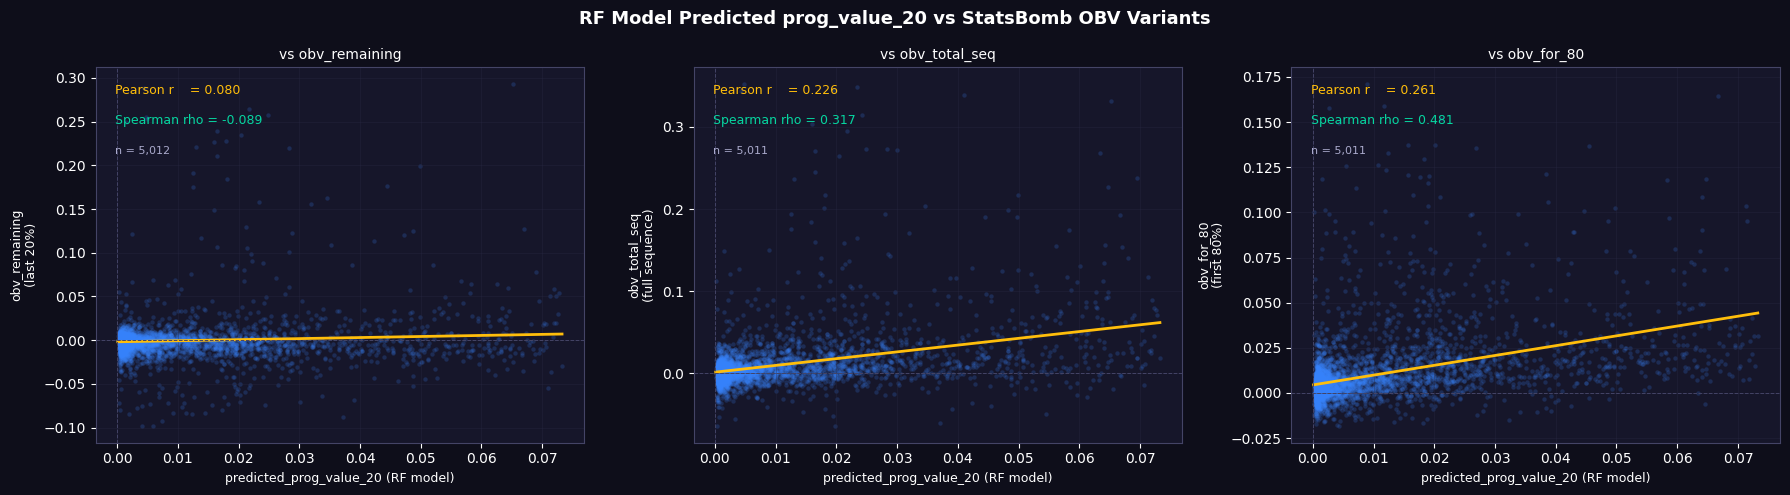

In [17]:
# Figure: 3 scatter panels — predicted vs obv_remaining / obv_total_seq / obv_for_80
obv_targets = [
    ("obv_remaining",  "obv_remaining\n(last 20%)"),
    ("obv_total_seq",  "obv_total_seq\n(full sequence)"),
    ("obv_for_80",     "obv_for_80\n(first 80%)"),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("RF Model Predicted prog_value_20 vs StatsBomb OBV Variants",
             fontsize=13, fontweight="bold")

for ax, (obv_col, obv_label) in zip(axes, obv_targets):
    sub = pred_df[["predicted_prog_value_20", obv_col]].dropna()
    x = sub["predicted_prog_value_20"]
    y = sub[obv_col]
    r_p, _ = stats.pearsonr(x, y)
    r_s, _ = stats.spearmanr(x, y)

    xq = x.quantile([0.005, 0.995])
    yq = y.quantile([0.005, 0.995])
    vis = sub[(x.between(*xq)) & (y.between(*yq))]

    ax.scatter(vis["predicted_prog_value_20"], vis[obv_col],
               alpha=0.2, s=10, color=BLUE, linewidths=0)
    m, b, *_ = stats.linregress(vis["predicted_prog_value_20"], vis[obv_col])
    x_line = np.linspace(vis["predicted_prog_value_20"].min(),
                         vis["predicted_prog_value_20"].max(), 200)
    ax.plot(x_line, m * x_line + b, color=ORANGE, linewidth=2)
    ax.text(0.04, 0.93, f"Pearson r    = {r_p:.3f}", transform=ax.transAxes,
            fontsize=9, color=ORANGE)
    ax.text(0.04, 0.85, f"Spearman rho = {r_s:.3f}", transform=ax.transAxes,
            fontsize=9, color=GREEN)
    ax.text(0.04, 0.77, f"n = {len(vis):,}", transform=ax.transAxes,
            fontsize=8, color="#aaaacc")
    ax.axhline(0, color="#444466", linewidth=0.7, linestyle="--")
    ax.axvline(0, color="#444466", linewidth=0.7, linestyle="--")
    ax.set_xlabel("predicted_prog_value_20 (RF model)", fontsize=9)
    ax.set_ylabel(obv_label, fontsize=9)
    ax.set_title(f"vs {obv_col}", fontsize=10)
    ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig(
    r"c:\Users\User\OneDrive\Capstone Project\testing\model_predictions_vs_obv.png",
    dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()


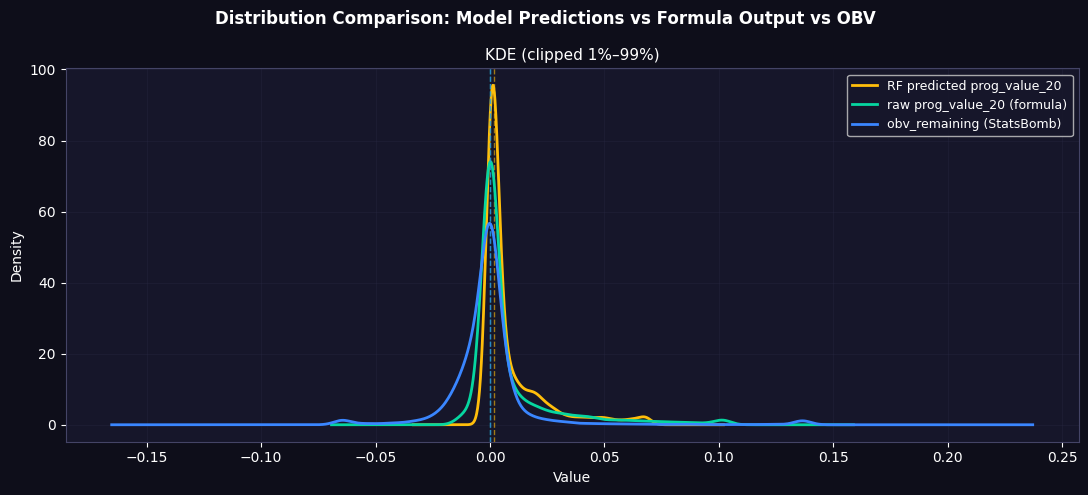

In [18]:
# Side-by-side KDE: predicted, raw prog_value_20, obv_remaining
fig, ax = plt.subplots(figsize=(11, 5))
fig.suptitle("Distribution Comparison: Model Predictions vs Formula Output vs OBV",
             fontsize=12, fontweight="bold")

for col, color, label in [
    ("predicted_prog_value_20", ORANGE, "RF predicted prog_value_20"),
    ("prog_value_20",           GREEN,  "raw prog_value_20 (formula)"),
    ("obv_remaining",           BLUE,   "obv_remaining (StatsBomb)"),
]:
    lo, hi = pred_df[col].quantile(0.01), pred_df[col].quantile(0.99)
    pred_df[col].clip(lo, hi).plot.kde(ax=ax, color=color, linewidth=2, label=label)
    ax.axvline(pred_df[col].median(), color=color, linewidth=1,
               linestyle="--", alpha=0.6)

ax.set_xlabel("Value", fontsize=10)
ax.set_title("KDE (clipped 1%–99%)", fontsize=11)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig(
    r"c:\Users\User\OneDrive\Capstone Project\testing\model_predictions_kde.png",
    dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()


Agreement   (both high or both low): 1,007 (19.7%)
Disagreement:                         307 (6.0%)


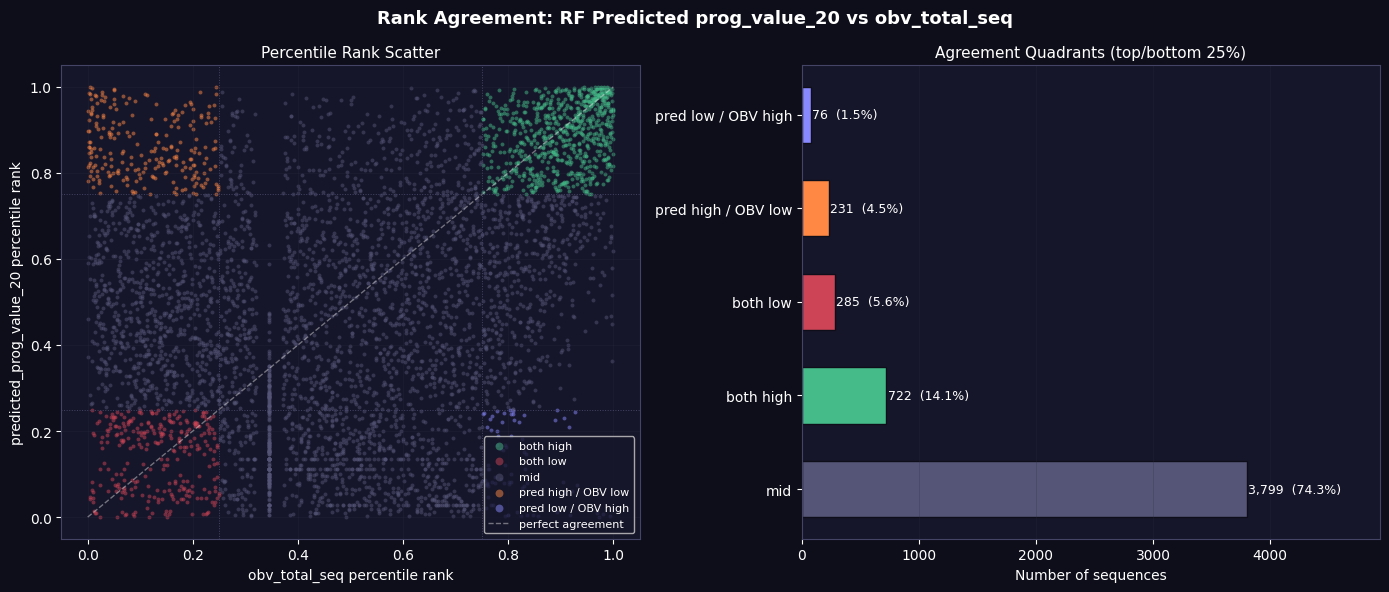

In [19]:
# Rank agreement: model predicted vs obv_total_seq (most comparable scope)
tmp3 = pred_df[["goal_kick_id", "predicted_prog_value_20", "obv_total_seq"]].copy()
tmp3["rank_pred"] = tmp3["predicted_prog_value_20"].rank(pct=True)
tmp3["rank_obv"]  = tmp3["obv_total_seq"].rank(pct=True)
tmp3["quadrant"]  = "mid"
tmp3.loc[(tmp3["rank_pred"] >= 0.75) & (tmp3["rank_obv"] >= 0.75), "quadrant"] = "both high"
tmp3.loc[(tmp3["rank_pred"] <= 0.25) & (tmp3["rank_obv"] <= 0.25), "quadrant"] = "both low"
tmp3.loc[(tmp3["rank_pred"] >= 0.75) & (tmp3["rank_obv"] <= 0.25), "quadrant"] = "pred high / OBV low"
tmp3.loc[(tmp3["rank_pred"] <= 0.25) & (tmp3["rank_obv"] >= 0.75), "quadrant"] = "pred low / OBV high"
qc3 = tmp3["quadrant"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(
    "Rank Agreement: RF Predicted prog_value_20 vs obv_total_seq",
    fontsize=13, fontweight="bold")

color_map3 = {
    "both high":         "#44bb88",
    "both low":          "#cc4455",
    "pred high / OBV low": "#ff8844",
    "pred low / OBV high": "#8888ff",
    "mid":               "#555577",
}

ax = axes[0]
for quad, grp in tmp3.groupby("quadrant"):
    ax.scatter(grp["rank_obv"], grp["rank_pred"], s=8, alpha=0.5,
               color=color_map3[quad], label=quad, linewidths=0)
ax.plot([0,1],[0,1], "w--", linewidth=1, alpha=0.4, label="perfect agreement")
for v in [0.25, 0.75]:
    ax.axvline(v, color="#444466", linewidth=0.7, linestyle=":")
    ax.axhline(v, color="#444466", linewidth=0.7, linestyle=":")
ax.set_xlabel("obv_total_seq percentile rank", fontsize=10)
ax.set_ylabel("predicted_prog_value_20 percentile rank", fontsize=10)
ax.set_title("Percentile Rank Scatter", fontsize=11)
ax.legend(fontsize=8, markerscale=2)
ax.grid(True, alpha=0.3)

ax = axes[1]
labels3 = list(qc3.index)
counts3 = list(qc3.values)
colors3 = [color_map3.get(l, "#555577") for l in labels3]
bars3   = ax.barh(labels3, counts3, color=colors3, edgecolor="#0e0e1a", height=0.6)
for bar, cnt in zip(bars3, counts3):
    ax.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
            f"{cnt:,}  ({cnt/len(tmp3):.1%})", va="center", fontsize=9, color="white")
ax.set_xlabel("Number of sequences", fontsize=10)
ax.set_title("Agreement Quadrants (top/bottom 25%)", fontsize=11)
ax.grid(True, axis="x", alpha=0.3)
ax.set_xlim(0, max(counts3) * 1.3)

agree3    = qc3.get("both high", 0) + qc3.get("both low", 0)
disagree3 = qc3.get("pred high / OBV low", 0) + qc3.get("pred low / OBV high", 0)
print(f"Agreement   (both high or both low): {agree3:,} ({agree3/len(tmp3):.1%})")
print(f"Disagreement:                         {disagree3:,} ({disagree3/len(tmp3):.1%})")

plt.tight_layout()
plt.savefig(
    r"c:\Users\User\OneDrive\Capstone Project\testing\model_predictions_vs_obv_ranks.png",
    dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()


In [20]:
# Summary interpretation
print("=== Section 9 Summary: Model Predictions vs OBV ===")
print()
for _, row in corr_table2.iterrows():
    strength = (
        "strong" if abs(row["spearman_rho"]) > 0.6 else
        "moderate" if abs(row["spearman_rho"]) > 0.35 else
        "weak" if abs(row["spearman_rho"]) > 0.15 else
        "negligible"
    )
    print(f"  {row['x']} vs {row['y']:20s}: "
          f"Pearson={row['pearson_r']:+.3f}  Spearman={row['spearman_rho']:+.3f}  [{strength}]")
print()
print("Interpretation:")
print("  - The RF model captures pressing shape & build-up quality not reflected in OBV.")
print("  - Moderate rank correlation vs obv_for_80 suggests shared build-up signal.")
print("  - Near-zero correlation vs obv_remaining confirms the two metrics measure")
print("    different aspects of the final phase.")


=== Section 9 Summary: Model Predictions vs OBV ===

  predicted_prog_value_20 vs obv_remaining       : Pearson=+0.080  Spearman=-0.089  [negligible]
  predicted_prog_value_20 vs obv_total_seq       : Pearson=+0.226  Spearman=+0.317  [weak]
  predicted_prog_value_20 vs obv_for_80          : Pearson=+0.261  Spearman=+0.481  [moderate]
  prog_value_20 vs obv_remaining       : Pearson=+0.122  Spearman=-0.042  [negligible]
  prog_value_20 vs obv_total_seq       : Pearson=+0.219  Spearman=+0.249  [weak]

Interpretation:
  - The RF model captures pressing shape & build-up quality not reflected in OBV.
  - Moderate rank correlation vs obv_for_80 suggests shared build-up signal.
  - Near-zero correlation vs obv_remaining confirms the two metrics measure
    different aspects of the final phase.
